In [1]:
import os
import re
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [237]:
# NOTES:

# which data to use
prefix = 'transect'

# dask cluster location
cluster_loc = 'hpc'

# cross-validation
tuneby_group = 'Year'
kfold_group = 'Year'

# one of 'logo' or 'group_k'
kfold_type = 'logo'
tune_kfold_type = 'logo'

use_cuda = False
# set backend as one of 'multiprocessing' or 'dask'
backend = 'dask' 

inDIR = '../data/training/'
inFILE = 'vor_2014_2023_cln_2024_04_04_' + prefix + '_s2_idxs_v7.csv'
nickname = 'cper_bm_' + prefix

inPATH = os.path.join(inDIR, inFILE)

outDIR = './results/'

outFILE_tmp = os.path.join(outDIR, 'tmp', re.sub('s2_idxs.csv', 'cv_' + kfold_group + '_tuneby_' + tuneby_group + '_tmp.csv', inFILE))

# unique ID column name
id_col = 'Id'
# date column name
date_col = 'Date_mean'
# dependent column name
y_col = 'Biomass_kg_ha'

In [238]:
# apply transformation to dependent variable
y_col_xfrm = False
def y_col_xfrm_func(x):
    return(x*10)

# apply transformation to the output of the CPER (2022) model
cper_mod_xfrm = False
def cper_mod_xfrm_func(x):
    # convert from kg/ha to lbs/acre
    return(x * 0.892179122)

var_names = [
    #'NDVI',
    'DFI',
    'NDTI',
    'SATVI',
    'NDII7',
    #'SAVI',
    'RDVI',
    'MTVI1',
    'NCI',
    #'NDCI',
    #'PSRI',
    #'NDWI',
    #'EVI', 
    #'TCBI', 'TCGI', 'TCWI',
    #'BAI_126', 'BAI_136', 'BAI_146', 'BAI_236', 'BAI_246', 'BAI_346',
    'BLUE', 'GREEN', 'RED', 
    'NIR1',
    'SWIR1', 'SWIR2',
    'RED-EDGE1', 
    'RED-EDGE2', 'RED-EDGE3', 'NIR-Broad'
]

gee_vis = ['NDVI', 
           'mARI', 
           'CHL-RED-EDGE', 
           'EVI', 
           'MCARI',
           'MSI', 
           #'NDMI',
           #'NDWI', 
           #'NDMI_MoistureStress',
           'NDCI',
           'PSSRb1',
           'SAVI',
           'SIPI',
           'PSRI',
           'VH_asc', 
           'VV_asc', 
           'VHVV_sum_asc', 
           'VHVV_diff_asc', 
           'VHVV_ratio_asc',
           'RVI_asc',
           #'VH_desc_lo', 
           #'VV_desc_lo', 
           #'VHVV_sum_desc_lo', 
           #'VHVV_diff_desc_lo', 
           #'VHVV_ratio_desc_lo',
           #'RVI_desc_lo',
           'VH_desc_hi', 
           'VV_desc_hi', 
           'VHVV_sum_desc_hi', 
           'VHVV_diff_desc_hi', 
           'VHVV_ratio_desc_hi',
           'RVI_desc_hi'
          ]

var_names = var_names+gee_vis

def load_df(inPATH, date_cols=[date_col]):
    # Preprocessing steps here
    df = pd.read_csv(inPATH, parse_dates=date_cols)
    
    df = df[df['Season'].isin(['June', 'October'])].copy()

    df = df[~df[var_names + [y_col]].isnull().any(axis=1)].copy()
    
    return df

In [231]:
df_raw = pd.read_csv('../data/raw_tmp/ts_raw_vor_transect_s2_v7.csv', parse_dates=['Date'])
#df_raw = pd.read_csv('../data/raw_tmp/ts_raw_vor_transect.csv', parse_dates=['Date'])

In [107]:
df_raw['Plot'] = df_raw[id_col].transform(lambda x: '_'.join(x.split('_')[:-1]))
df_raw = df_raw.drop(columns=['Id']).groupby(['Plot', 'Date']).mean().reset_index()
df_raw['Id'] = df_raw['Plot']

In [232]:
id = df_raw['Id'].unique()[0]

<Axes: xlabel='Date', ylabel='SWIR1'>

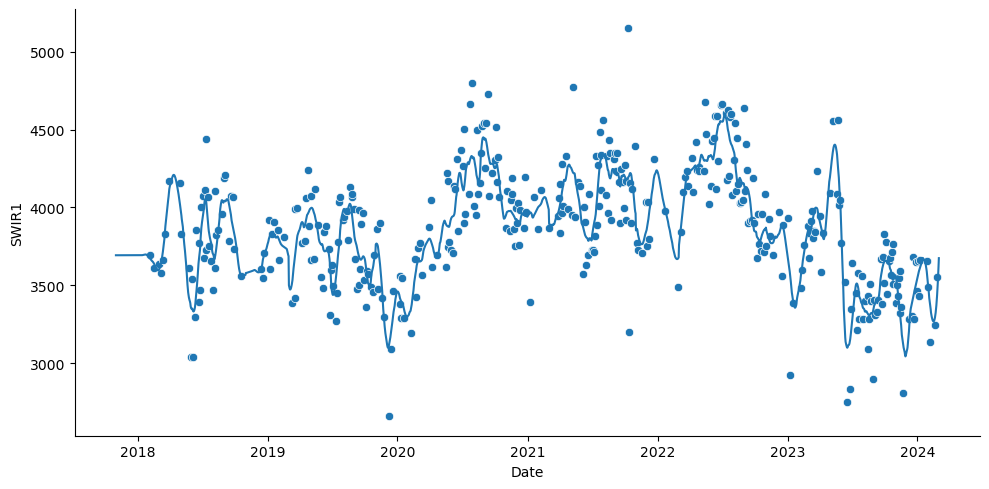

In [109]:
p = sns.relplot(x='Date', y='SWIR1',
            data=df_raw[df_raw['Id'] == id], aspect=2)
sns.lineplot(x='Date', y='SWIR1_smooth',
            data=df_raw[df_raw['Id'] == id], ax=p.axes.flatten()[0])

<Axes: xlabel='Date', ylabel='VHVV_ratio_desc_hi'>

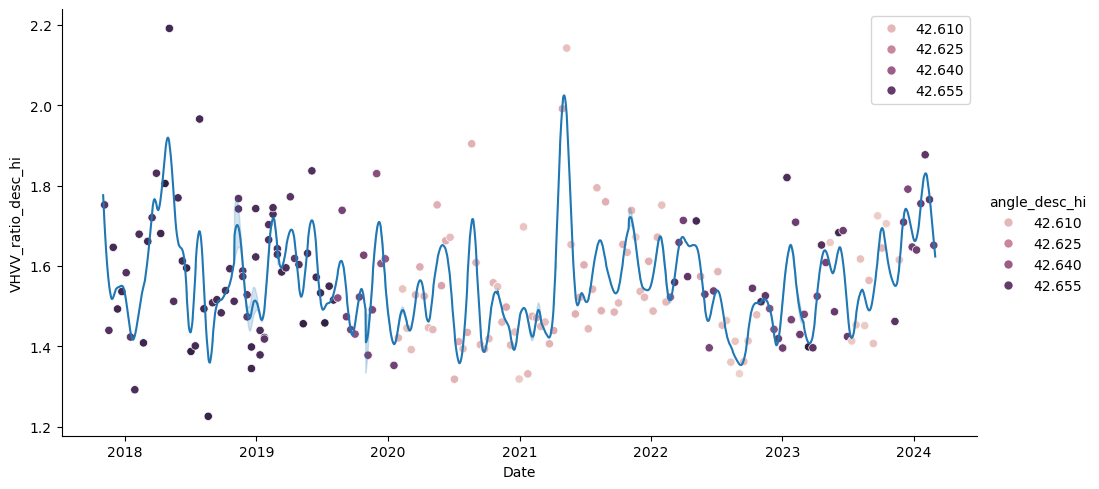

In [235]:
p = sns.relplot(x='Date', y='VHVV_ratio_desc_hi', hue='angle_desc_hi',
            data=df_raw[df_raw['Id'] == id], aspect=2)
sns.lineplot(x='Date', y='VHVV_ratio_desc_hi_smooth',
            data=df_raw[df_raw['Id'] == id], ax=p.axes.flatten()[0])

<Axes: xlabel='Date', ylabel='VHVV_sum_asc'>

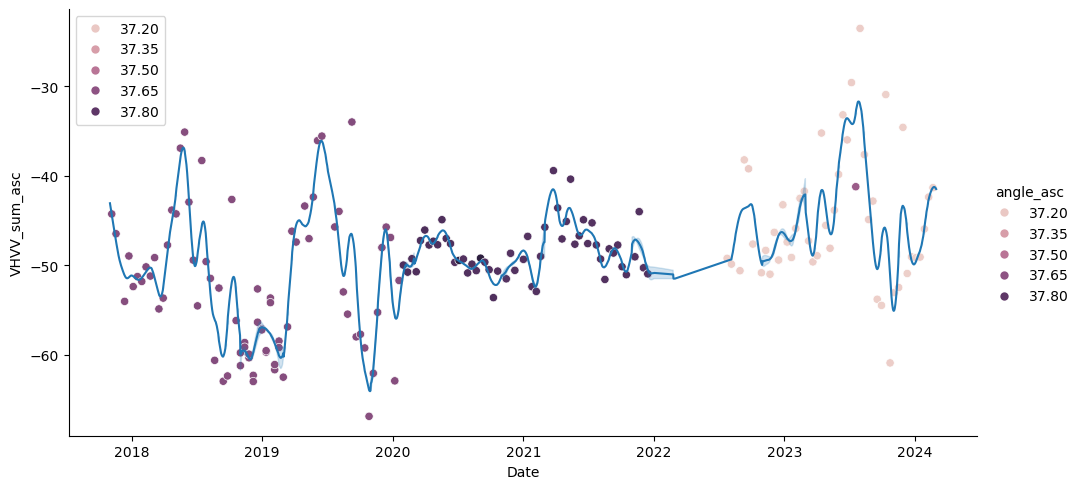

In [236]:
p = sns.relplot(x='Date', y='VHVV_sum_asc', hue='angle_asc',
            data=df_raw[df_raw['Id'] == id], aspect=2)
sns.lineplot(x='Date', y='VHVV_sum_asc_smooth',
            data=df_raw[df_raw['Id'] == id], ax=p.axes.flatten()[0])

In [239]:
df = load_df(inPATH, ['Date', 'Date_mean'])

In [240]:
#df['Plot'] = df[id_col].transform(lambda x: '_'.join(x.split('_')[:-1]))
#df = df.drop(columns=['Id', 'Pasture', 'Season', 'geometry']).groupby(['Plot', 'Date_mean']).mean().reset_index()
#df['Id'] = df['Plot']

In [241]:
df['sqrt_Biomass_kg_ha'] = np.sqrt(df['Biomass_kg_ha'])

In [242]:
#sns.displot(x='BLUE', hue='Year', col='Season', data=df, palette='tab10', kind='kde')

In [19]:
#df2 = load_df(re.sub('_v2', '', inPATH), ['Date', 'Date_mean'])
df2 = pd.read_csv(os.path.join(inDIR, 'vor_2014_2023_cln_2024_04_04_' + prefix + '_hls_idxs.csv'),
                  parse_dates=['Date', 'Date_mean'])
#df2['Date'] = 

In [20]:
df2 = df2[df2['Year'] >= 2018]
df2['sqrt_Biomass_kg_ha'] = np.sqrt(df2['Biomass_kg_ha'])

In [21]:
df3 = pd.merge(df, df2, how='left', on=['Date', 'Date_mean', 'Id', 'Year'])

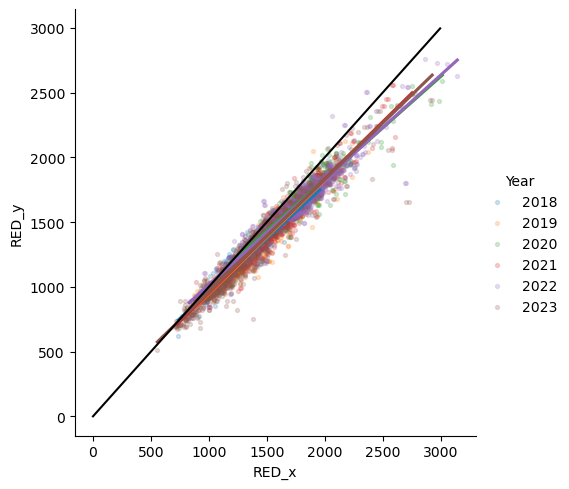

In [22]:
p = sns.lmplot(df3,
           x='RED_x', y='RED_y',
           facet_kws=dict(sharey=False, sharex=False,),
           hue=kfold_group, ci=None,
           scatter_kws={'s': 8, 'alpha': 0.2, 'edgecolor': None})
p.axes.flatten()[0].plot(np.arange(0, 3000,5), np.arange(0, 3000, 5), c='black')

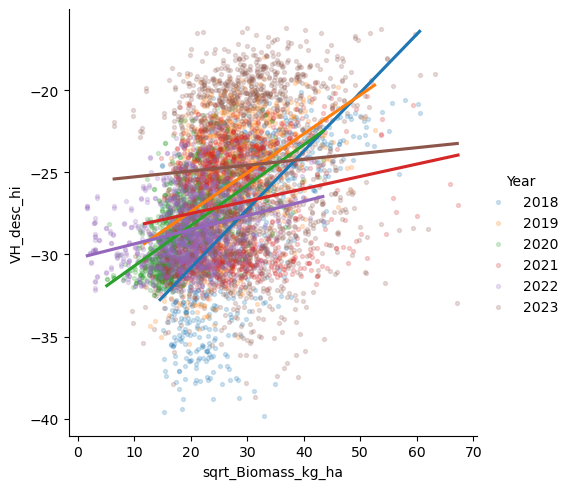

In [115]:
sns.lmplot(df,
           x='sqrt_Biomass_kg_ha', y='VH_desc_hi',
           facet_kws=dict(sharey=False, sharex=False,),
           hue=kfold_group, ci=None,
           scatter_kws={'s': 8, 'alpha': 0.2, 'edgecolor': None})

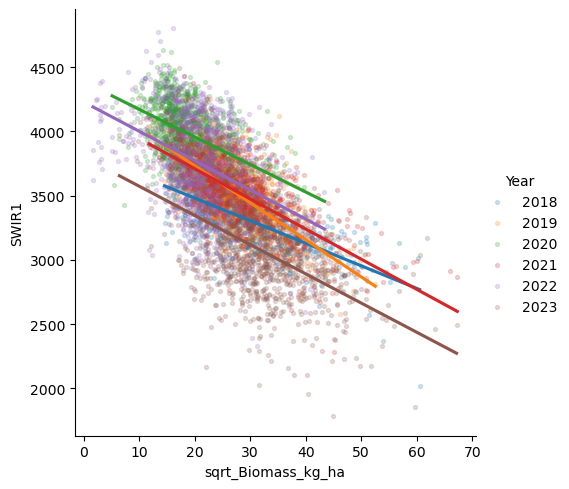

In [27]:
sns.lmplot(df2,
           x='sqrt_Biomass_kg_ha', y='SWIR1',
           facet_kws=dict(sharey=False, sharex=False,),
           hue=kfold_group, ci=None,
           scatter_kws={'s': 8, 'alpha': 0.2, 'edgecolor': None})

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from joblib import parallel_backend
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm
from sklearn.metrics import r2_score

In [29]:
from dask.distributed import LocalCluster, Client
import dask
#from jupyter_server import serverapp
#try:
#    jupServer = [x for x in serverapp.list_running_servers()][0]
#except IndexError:
#    # manually copy/paste the server address
#    jupServer = {'base_url': '/node/ceres19-compute-98-eth.scinet.local/17710/'}
#dask.config.set({'distributed.dashboard.link': jupServer['base_url'] + 'proxy/{port}/status'})
cluster = LocalCluster(n_workers=36, threads_per_worker=2)
client = Client(cluster)
display(client)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 36
Total threads: 72,Total memory: 270.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41409,Workers: 36
Dashboard: http://127.0.0.1:8787/status,Total threads: 72
Started: Just now,Total memory: 270.21 GiB
Comm: tcp://127.0.0.1:35435,Total threads: 2
Dashboard: http://127.0.0.1:40119/status,Memory: 7.51 GiB
Nanny: tcp://127.0.0.1:33201,


In [243]:
def vip(x, y, model):
    #https://omicsforum.ca/t/the-calculation-of-vip-score-in-pls-da-module/3312
    t = model.x_scores_
    #w = model.x_weights_
    w = model.x_rotations_
    q = model.y_loadings_

    p, h = w.shape
    #m, p = x.shape
    #_, h = t.shape

    vips = np.zeros((p,))

    s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)
    total_s = np.sum(s)

    for i in range(p):
        weight = np.array([ (w[i,j] / np.linalg.norm(w[:,j]))**2 for j in range(h) ])
        vips[i] = np.sqrt(p*(s.T @ weight)/total_s).item()

    return vips

In [244]:
#df = df2.copy()
#df = df[df['Year'] >= 2018]
#df2_vars = [x for x in var_names if x not in ['RED-EDGE1', 'RED-EDGE2', 'RED-EDGE3', 'NIR-Broad']]
#var_names = df2_vars
#df = df[~df[var_names+[y_col]].isna().any(axis=1)]

In [245]:
mod_split = LeaveOneGroupOut()

scoring = {
        'R2': 'r2',
        #'MSE': 'neg_mean_squared_error',
        'MAE': 'neg_mean_absolute_error',
        #'MAPE': 'neg_mean_absolute_percentage_error',
        #'MSLE': 'neg_mean_squared_log_error'
    }

mod_base = Pipeline(
    [
        #('encoder', trf_ecosite),
        ('scaler', StandardScaler()), 
        ('PLS', PLSRegression(n_components=1, scale=False))
    ])

param_grid = {
     'PLS__n_components': [int(x) for x in np.arange(1, len(var_names))]
    #'PLS__n_components': [int(x) for x in np.arange(1, 4)]
}

y_col = 'sqrt_Biomass_kg_ha'

mod_dict = {}

test_vip = True
pred_interval = False
pred_smooth = False
df_vip = pd.DataFrame()

In [ ]:
for train_index, test_index in mod_split.split(df[var_names], groups=df[kfold_group]):
    logo_test = df[kfold_group].iloc[test_index].unique()
    logo_k = logo_test[0]
    
    train_loc = df.iloc[train_index].index
    test_loc = df.iloc[test_index].index
    
    all_y = df[y_col].iloc[train_index]
    all_Y = df[y_col].iloc[test_index]
    all_x = df[var_names].iloc[train_index, :]
    all_X = df[var_names].iloc[test_index, :]
       
    # tune the model
    if tuneby_group=='new_kfold':
        split_groups = pd.Series(np.ones(all_x.shape[0])*np.nan, index=all_x.index)
        n_splits = 5
        # Initialize KFold
        kf_new = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        # Assign groups
        for fold, (train_idx_new, test_idx_new) in enumerate(kf_new.split(all_x)):
            split_groups.iloc[test_idx_new] = fold
    else:
        split_groups = df[tuneby_group].iloc[train_index]
    cv_splitter = mod_split.split(all_x, groups=split_groups)

    grid_search = GridSearchCV(estimator=mod_base,
                               param_grid=param_grid,
                               scoring=scoring, 
                               refit='R2', 
                               return_train_score=True,
                               cv=cv_splitter, 
                               n_jobs=min(sum([len(x) for x in param_grid]), 16))
    with parallel_backend('threading'):
        #with warnings.catch_warnings():
        #    warnings.simplefilter("ignore", category=ConvergenceWarning)
        grid_search.fit(all_x, all_y)
        mod_fnl = mod_base.set_params(**grid_search.best_params_)
        mod_fnl.fit(all_x, all_y)
        mod_dict[logo_k] = grid_search.cv_results_
    
    preds = mod_fnl.predict(all_X).squeeze()
    preds[preds < 0] = 0
    df.loc[test_loc, 'PLS_pred'] = preds
    df.loc[test_loc, 'kfold'] = logo_k

    if pred_smooth:
        test_loc_smooth = df_smooth[df_smooth['Id'].isin(df.loc[test_loc, 'Id']) &
        df_smooth['Year'].isin(df.loc[test_loc, 'Year'])].index
        df_smooth.loc[test_loc_smooth, 'PLS_pred'] = mod_fnl.predict(df_smooth.loc[test_loc_smooth, var_names])
    
    if pred_interval:
        predsHolder = []
        if pred_smooth:
            predsHolder_smooth = []
        for b in tqdm(range(100)):
            all_x_sub = all_x.sample(frac=0.9)
            all_y_sub = all_y.loc[all_x_sub.index]
            mod_tmp = mod_fnl
            mod_tmp.fit(all_x_sub, all_y_sub)
            preds_tmp = mod_tmp.predict(all_X).squeeze()
            predsHolder.append(pd.Series(preds_tmp, name='predy_' + str(b)))
            if pred_smooth:
                preds_smooth_tmp = mod_tmp.predict(df_smooth.loc[test_loc_smooth, var_names]).squeeze()
                predsHolder_smooth.append(pd.Series(preds_smooth_tmp, name='predy_' + str(b)))
        df_predsHolder = pd.concat(predsHolder, axis=1)
        df_caseHolder = df_predsHolder.copy()
        if pred_smooth:
            df_predsHolder_smooth = pd.concat(predsHolder_smooth, axis=1)
            df_caseHolder_smooth = df_predsHolder_smooth.copy()
        for b in range(100):
            # randomly add residual back in as either positive or negative?
            df_caseHolder['predy_' + str(b)] = df_predsHolder['predy_' + str(b)] +\
            [-1, 1][np.random.randint(2)] * \
            (all_Y - df_predsHolder.apply(lambda x: x['predy_' + str(np.random.randint(100))], axis=1).values).values
            
        #df_caseHolder = df_predsHolder + rand_resid.values
        df.loc[test_loc, 'PLS_pred_AvgStd'] = df_predsHolder.std(axis=1).values
        df.loc[test_loc, 'PLS_pred_CaseStd'] = df_caseHolder.std(axis=1).values
        df.loc[test_loc, 'PLS_pred_PIlo10'] = df_caseHolder.quantile(0.10, axis=1).values
        df.loc[test_loc, 'PLS_pred_PIhi90'] = df_caseHolder.quantile(0.90, axis=1).values
        if pred_smooth:
            case_resid_avg = np.abs(df_predsHolder - df_caseHolder).mean(axis=0)
            for b in range(100):
                 df_caseHolder_smooth['predy_' + str(b)] = df_predsHolder_smooth['predy_' + str(b)] +\
                [-1, 1][np.random.randint(2)] * case_resid_avg['predy_' + str(np.random.randint(100))]
            df_smooth.loc[test_loc_smooth, 'PLS_pred_AvgStd'] = df_predsHolder_smooth.std(axis=1).values
            df_smooth.loc[test_loc_smooth, 'PLS_pred_CaseStd'] = df_caseHolder_smooth.std(axis=1).values
            df_smooth.loc[test_loc_smooth, 'PLS_pred_PIlo10'] = df_caseHolder_smooth.quantile(0.10, axis=1).values
            df_smooth.loc[test_loc_smooth, 'PLS_pred_PIhi90'] = df_caseHolder_smooth.quantile(0.90, axis=1).values
   
    if test_vip:
        var_names_out = var_names
        pls_vip = vip(all_x, all_y, mod_fnl['PLS'])
        pls_coefs = abs(mod_fnl['PLS'].coef_).squeeze()
        #all_x_vip = all_x.copy()
        #for i in range(3):
        #vip_thresh = 0.8
        #all_x_vip = all_x_vip[all_x_vip.columns[pls_vip > vip_thresh]]
        #mod_fnl.fit(all_x_vip, all_y)
        #var_names_out = [x for idx, x in enumerate(var_names_out) if pls_vip[idx] > vip_thresh]
        #pls_vip = vip(all_x_vip, all_y, mod_fnl['PLS'])
        #pls_coefs = abs(mod_fnl['PLS'].coef_).squeeze()
            
        df_vip = pd.concat([df_vip,
                            pd.DataFrame({'kfold': logo_k,
                                          'Variable': var_names_out,
                                          'VIP': pls_vip,
                                          'Coef': pls_coefs})])

In [ ]:
k = 'PLS'
param_dfs = {}
for idx, kfold in enumerate(mod_dict):
    if idx == 0:
        param_names = list(np.unique([list(x.keys()) for x in mod_dict[kfold]['params']]))
        #param_dfs[k] = pd.DataFrame(columns=['Model', 'kfold', 'Best', 'MAE'] + param_names)
    df_tmp = pd.DataFrame({'Model': 'PLS',
                           'kfold': str(kfold),
                           'Best': 0,
                           'MAE': mod_dict[kfold]['mean_test_MAE'],
                           'R2': mod_dict[kfold]['mean_test_R2'],
                           #'R2_train': mod_dict[k]['tune_results'][kfold]['mean_train_R2']
                          })
    for p in param_names:
        df_tmp[p] = mod_dict[kfold]['param_' + p].data
    idx_best = mod_dict[kfold]['rank_test_MAE'].argmin()
    df_tmp.loc[idx_best, 'Best'] = 1
    if idx == 0:
        param_dfs[k] = df_tmp
    else:
        param_dfs[k] = pd.concat([param_dfs[k], df_tmp.dropna(how='all', axis=0)])
if k in param_dfs.keys():
    param_dfs[k] = param_dfs[k].reset_index(drop=True)

In [ ]:
p = sns.catplot(x='PLS__n_components', y='R2', data=param_dfs['PLS'], hue='kfold', kind='point', aspect=2)
p.axes.flatten()[0].set_ylim((0, 1.0))

In [ ]:
sns.catplot(x='PLS__n_components', y='MAE', data=param_dfs['PLS'], hue='kfold', kind='point', aspect=2)

In [ ]:
#df_vip['Variable'].unique()

In [ ]:
df_pls_coefs = df_vip
df_pls_coefs['kfold'] = pd.Categorical(df_pls_coefs['kfold'], categories=df_pls_coefs['kfold'].sort_values().unique())
df_pls_coefs_ranked = df_pls_coefs.groupby('Variable', observed=True)['VIP'].mean().sort_values(ascending=False)
df_pls_coefs['Variable'] = pd.Categorical(df_pls_coefs['Variable'], categories=df_pls_coefs_ranked.index.values)
df_pls_coefs_top = df_pls_coefs[df_pls_coefs['VIP'] > 1.0].copy()
df_pls_coefs_top['Variable'] = df_pls_coefs_top['Variable'].cat.remove_unused_categories()
df_pls_coefs['Model'] = 'PLS'
df_pls_coefs['VI'] = df_pls_coefs['VIP']

In [ ]:
fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(5, 8), 
                        sharex=False, sharey=False)
idx=1
df_tmp = df_pls_coefs
df_tmp['Variable'] = df_tmp['Variable'].apply(lambda x: re.sub('_', '', x))
#top_vars = [x for x in df_tmp['Variable'].unique() if df_tmp[df_tmp['Variable'] == x]['VI'].mean() >= 1.0]
top_vars = [x for x in df_tmp['Variable'].unique() if np.all(df_tmp[df_tmp['Variable'] == x]['VI'] >= 1.0)]
#bottom_vars = [x for x in df_tmp['Variable'].unique() if df_tmp[df_tmp['Variable'] == x]['VI'].mean() < 1.0]
bottom_vars = [x for x in df_tmp['Variable'].unique() if np.all(df_tmp[df_tmp['Variable'] == x]['VI'] < 1.0)]
sns.stripplot(y='Variable', x='VI', data=df_tmp, size=4,
              hue='kfold', orient='h',
              ax=axs, legend=False)
for ytick in axs.get_yticklabels():
    if ytick.get_text() in top_vars:
        ytick.set_fontweight(800)
    elif ytick.get_text() in bottom_vars:
        ytick.set_fontweight(100)
        ytick.set_color('grey')
axs.yaxis.set_tick_params(labelsize=8)
axs.axvline(x=1.0, linestyle='dotted', color='grey')
axs.set_title(df_tmp['Model'].unique()[0], fontweight=10)
#if idx > 3:
#    axs.flatten()[idx].set_xlabel('Variable importance')
#else:
axs.set_xlabel(None)
axs.set_ylabel(None)
plt.tight_layout()

In [ ]:
def r_corrcoef(y_obs, y_pred):
    corr_matrix = np.corrcoef(y_obs, y_pred)
    corr = corr_matrix[0,1]
    r = corr
    return r

In [ ]:
df_pred = df.copy()
df_bm_pred = df_pred.rename(columns={'PLS_pred': 'Predicted_xfrm',
                        'sqrt_Biomass_kg_ha': 'Observed_xfrm',
                        'Biomass_kg_ha': 'Observed'})
if 'sqrt' in y_col:
    df_bm_pred['Predicted'] = df_bm_pred['Predicted_xfrm']**2
else:
    df_bm_pred['Predicted'] = df_bm_pred['Predicted_xfrm']
    df_bm_pred['Observed_xfrm'] = df_bm_pred['Observed']
if 'Plot' not in df_bm_pred.columns:
    df_bm_pred['Plot'] = df_bm_pred[id_col].transform(lambda x: '_'.join(x.split('_')[:-1]))
max_lim = max(df_bm_pred[['Observed', 'Predicted']].max())*1.1
max_lim_xfrm = max(df_bm_pred[['Observed_xfrm', 'Predicted_xfrm']].max())*1.1

logo_group = kfold_group
save_results=False

In [ ]:
if 'transect' in inPATH:
    mae_transect = df_bm_pred.groupby([logo_group], observed=True).apply(
        lambda z: z.groupby([id_col, date_col]).apply(
            lambda x: abs(np.mean(x['Predicted_xfrm']) - np.mean(x['Observed_xfrm'])), 
            include_groups=False).mean(), include_groups=False).round(4)
    bias_transect = df_bm_pred.groupby([logo_group], observed=True).apply(
        lambda z: z.groupby([date_col]).apply(
            lambda x: np.mean(x['Predicted_xfrm']) - np.mean(x['Observed_xfrm']),
            include_groups=False).mean(), include_groups=False).round(4)
    mae_bt_transect = df_bm_pred.groupby([logo_group], observed=True).apply(
        lambda z: z.groupby([id_col, date_col]).apply(
            lambda x: abs(np.mean(x['Predicted']) - np.mean(x['Observed'])), 
            include_groups=False).mean(), include_groups=False).round(4)
    bias_bt_transect = df_bm_pred.groupby([logo_group], observed=True).apply(
        lambda z: z.groupby([id_col, date_col]).apply(
            lambda x: np.mean(x['Predicted']) - np.mean(x['Observed']), 
            include_groups=False).mean(), include_groups=False).round(4)
    r2_transect = df_bm_pred.groupby([logo_group, id_col, date_col], 
                                 observed=True)[['Observed_xfrm', 'Predicted_xfrm']].mean().reset_index().dropna().groupby(
        [logo_group], observed=True).apply(
        lambda x: r2_score(x['Observed_xfrm'], x['Predicted_xfrm']), 
        include_groups=False).round(4)
    r2_corr_transect = df_bm_pred.groupby([logo_group, id_col, date_col], 
                                 observed=True)[['Observed_xfrm', 'Predicted_xfrm']].mean().reset_index().dropna().groupby(
        [logo_group], observed=True).apply(
            lambda x: r_corrcoef(x['Observed_xfrm'], x['Predicted_xfrm']),
        include_groups=False).round(4)

    df_smry_transect = pd.DataFrame({
        'MAE': mae_transect.mean().round(4),
        'MAE_std': mae_transect.std().round(4),
        'Bias': bias_transect.mean().round(4),
        'Bias_std': bias_transect.std().round(4),
        'R^2': r2_transect.mean().round(4),
        'R^2_std': r2_transect.std().round(4),
        'r': r2_corr_transect.mean().round(4),
        'r_std': r2_corr_transect.std().round(4),
        'MAE_bt': mae_bt_transect.mean().round(4),
        'MAE_bt_std': mae_bt_transect.std().round(4),
        'MAE_bt_pct': (mae_bt_transect / df_bm_pred.groupby([logo_group], 
                                                        observed=True)['Observed'].mean()).mean().round(4),
        'MAE_bt_pct_std': (mae_bt_transect / df_bm_pred.groupby([logo_group], 
                                                        observed=True)['Observed'].mean()).std().round(4),
        'Bias_bt': bias_bt_transect.mean().round(4),
        'Bias_bt_std': bias_bt_transect.std().round(4),
    }, index=[0])
    display(df_smry_transect)
    if save_results:
        df_smry_transect.to_csv(os.path.join(outDIR,
                                             'tables/ml_models', 
                                             re.sub('tmp.csv', 'results_transect.csv', os.path.basename(inPATH))))
    
    df_smry_transect_by_yr = pd.DataFrame({
        'MAE': mae_transect.round(4),
        'Bias': bias_transect.round(4),
        'MAE_bt': mae_bt_transect.round(4),
        'MAE_pct': (mae_bt_transect / df_bm_pred.groupby([logo_group], observed=True)['Observed'].mean()).round(4),
        'R^2': r2_transect.round(4),
        'r': r2_corr_transect.round(4)
    })
    #display(df_smry_transect_by_yr)
    if save_results:
        df_smry_transect_by_yr.to_csv(os.path.join(outDIR,
                                                   'tables/ml_models', 
                                                   re.sub('tmp.csv', 'results_transect_yrly.csv', os.path.basename(inPATH))))

    p_transect = sns.lmplot(df_bm_pred.groupby([logo_group, id_col, date_col], 
                                           observed=True)[['Observed', 'Predicted']].mean().reset_index(),
                   x='Observed', y='Predicted',
                        facet_kws=dict(sharey=False, sharex=False,),
                        hue=logo_group, ci=None,
                        scatter_kws={'s': 8, 'alpha': 0.2, 'edgecolor': None})
    for ax in p_transect.axes.flatten():
        ax.set_ylim((0, max_lim))
        ax.plot(np.arange(0, max_lim), np.arange(0, max_lim), c='black')
    if save_results:
        plt.savefig(os.path.join(outDIR, 
                                 'figures/ml_models',
                                 re.sub('tmp.csv', 'results_transect.png', os.path.basename(inPATH))), dpi=100)

In [ ]:
mae_plot = df_bm_pred.groupby([logo_group], observed=True).apply(
    lambda z: z.groupby(['Plot', date_col]).apply(
        lambda x: abs(np.mean(x['Predicted_xfrm']) - np.mean(x['Observed_xfrm'])), 
        include_groups=False).mean(), include_groups=False).round(4)
bias_plot = df_bm_pred.groupby([logo_group], observed=True).apply(
    lambda z: z.groupby(['Plot', date_col]).apply(
        lambda x: np.mean(x['Predicted_xfrm']) - np.mean(x['Observed_xfrm']),
        include_groups=False).mean(), include_groups=False).round(4)
mae_bt_plot = df_bm_pred.groupby([logo_group], observed=True).apply(
    lambda z: z.groupby(['Plot', date_col]).apply(
        lambda x: abs(np.mean(x['Predicted']) - np.mean(x['Observed'])), 
        include_groups=False).mean(), include_groups=False).round(4)
bias_bt_plot = df_bm_pred.groupby([logo_group], observed=True).apply(
    lambda z: z.groupby(['Plot', date_col]).apply(
        lambda x: np.mean(x['Predicted']) - np.mean(x['Observed']), 
        include_groups=False).mean(), include_groups=False).round(4)
r2_plot = df_bm_pred.groupby([logo_group, 'Plot', date_col], 
                             observed=True)[['Observed_xfrm', 'Predicted_xfrm']].mean().reset_index().dropna().groupby(
    [logo_group], observed=True).apply(
    lambda x: r2_score(x['Observed_xfrm'], x['Predicted_xfrm']), 
    include_groups=False).round(4)
r2_corr_plot = df_bm_pred.groupby([logo_group, 'Plot', date_col], 
                             observed=True)[['Observed_xfrm', 'Predicted_xfrm']].mean().reset_index().dropna().groupby(
    [logo_group], observed=True).apply(
        lambda x: r_corrcoef(x['Observed_xfrm'], x['Predicted_xfrm']),
    include_groups=False).round(4)

In [ ]:
df_smry_plot = pd.DataFrame({
    'MAE': mae_plot.mean().round(4),
    'MAE_std': mae_plot.std().round(4),
    'Bias': bias_plot.mean().round(4),
    'Bias_std': bias_plot.std().round(4),
    'R^2': r2_plot.mean().round(4),
    'R^2_std': r2_plot.std().round(4),
    'r': r2_corr_plot.mean().round(4),
    'r_std': r2_corr_plot.std().round(4),
    'MAE_bt': mae_bt_plot.mean().round(4),
    'MAE_bt_std': mae_bt_plot.std().round(4),
    'MAE_bt_pct': (mae_bt_plot / df_bm_pred.groupby([logo_group], 
                                                    observed=True)['Observed'].mean()).mean().round(4),
    'MAE_bt_pct_std': (mae_bt_plot / df_bm_pred.groupby([logo_group], 
                                                    observed=True)['Observed'].mean()).std().round(4),
    'Bias_bt': bias_bt_plot.mean().round(4),
    'Bias_bt_std': bias_bt_plot.std().round(4),
}, index=[0])
display(df_smry_plot)
if save_results:
    df_smry_plot.to_csv(os.path.join(outDIR,
                                     'tables/ml_models', 
                                     re.sub('tmp.csv', 'results_plot.csv', os.path.basename(inPATH))))

df_smry_plot_by_yr = pd.DataFrame({
    'MAE': mae_plot.round(4),
    'Bias': bias_plot.round(4),
    'MAE_bt': mae_bt_plot.round(4),
    'MAE_pct': (mae_bt_plot / df_bm_pred.groupby([logo_group], observed=True)['Observed'].mean()).round(4),
    'R^2': r2_plot.round(4),
    'r': r2_corr_plot.round(4)
})
#display(df_smry_plot_by_yr)
if save_results:
    df_smry_plot_by_yr.to_csv(os.path.join(outDIR, 
                                           'tables/ml_models', 
                                           re.sub('tmp.csv', 'results_plot_yrly.csv', os.path.basename(inPATH))))

In [ ]:
df_smry_plot_by_yr

In [ ]:
p_plot = sns.lmplot(df_bm_pred.groupby([logo_group, 'Plot', date_col], 
                                       observed=True)[['Observed_xfrm', 'Predicted_xfrm']].mean().reset_index(),
               x='Observed_xfrm', y='Predicted_xfrm',
                    facet_kws=dict(sharey=False, sharex=False,),
                    hue=logo_group, ci=None,
                    scatter_kws={'s': 8, 'alpha': 0.2, 'edgecolor': None})
for ax in p_plot.axes.flatten():
    ax.set_ylim((0, max_lim_xfrm))
    ax.plot(np.arange(0, max_lim_xfrm), np.arange(0, max_lim_xfrm), c='black')
if save_results:
    plt.savefig(os.path.join(outDIR, 
                             'figures/ml_models', 
                             re.sub('tmp.csv', 'results_plot.png', os.path.basename(inPATH))), dpi=100)

### Fit overall model and compare to saved HLS model

In [50]:
from sklearn import compose

In [47]:
mod_fnl = mod_base.set_params(**{'PLS__n_components': 3})

In [48]:
xfrm_y = exec('lambda x: np.sqrt(x)')
bxfrm_y = exec('lambda x: x**2')

In [51]:
regr_base = compose.TransformedTargetRegressor(regressor=mod_fnl,
                                          func=xfrm_y,
                                          inverse_func=bxfrm_y)

In [52]:
regr = regr_base.fit(df[var_names], df['Biomass_kg_ha'])

In [53]:
df['predy'] = regr.predict(df[var_names])
df.loc[df['predy'] < 0, 'predy'] = 0

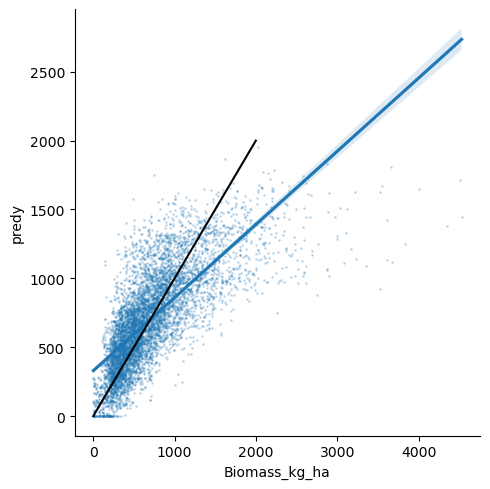

In [54]:
p = sns.lmplot(x='Biomass_kg_ha', y='predy', data=df, scatter_kws={'s': 1, 'alpha': 0.2})
p.axes.flatten()[0].plot(np.arange(0, 2000), np.arange(0,2000), c='k')

In [55]:
var_names2 = [
    'NDVI',
    'DFI',
    'NDTI',
    'SATVI',
    'NDII7',
    'SAVI',
    'RDVI',
    'MTVI1',
    'NCI',
    'NDCI',
    'PSRI',
    'NDWI',
    'EVI', 
    'TCBI', 'TCGI', 'TCWI',
    'BAI_126', 'BAI_136', 'BAI_146', 'BAI_236', 'BAI_246', 'BAI_346',
    'BLUE', 'GREEN', 'RED', 'NIR1', 'SWIR1', 'SWIR2',
    #'RED-EDGE1', 'RED-EDGE2', 'RED-EDGE3', 'NIR-Broad'
]
regr2 = regr.fit(df2.dropna(subset=var_names2+['Biomass_kg_ha'])[var_names2], 
                 df2.dropna(subset=var_names2+['Biomass_kg_ha'])['Biomass_kg_ha'])

In [56]:
df2['predy'] = regr2.predict(df2[var_names2])
df2.loc[df2['predy'] < 0, 'predy'] = 0

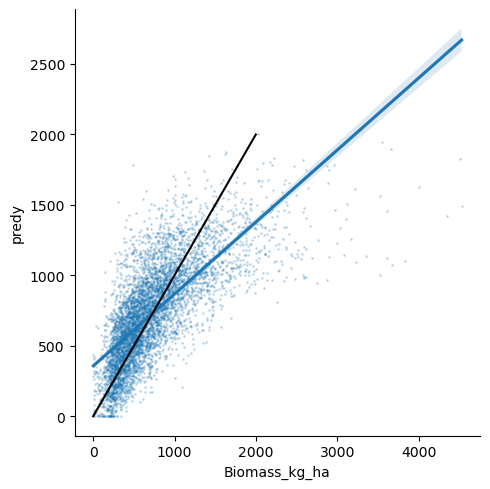

In [57]:
p = sns.lmplot(x='Biomass_kg_ha', y='predy', data=df2, scatter_kws={'s': 1, 'alpha': 0.2})
p.axes.flatten()[0].plot(np.arange(0, 2000), np.arange(0,2000), c='k')

In [58]:
import pickle
mod_hls = pickle.load(open('/project/cper_neon_aop/hls_nrt_utils/hlsstack/models/CPER_HLS_to_VOR_biomass_model_pls_20241015.pk', 'rb'))

/project/cper_neon_aop/conda_envs/py_ml_env/lib/python3.9/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.1.post1 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/project/cper_neon_aop/conda_envs/py_ml_env/lib/python3.9/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PLSRegression from version 1.4.1.post1 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/project/cper_neon_aop/conda_envs/py_ml_env/lib/python3.9/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle

In [59]:
df2['predy_orig'] = mod_hls.predict(df2[var_names2])
df2.loc[df2['predy_orig'] < 0, 'predy_orig'] = 0

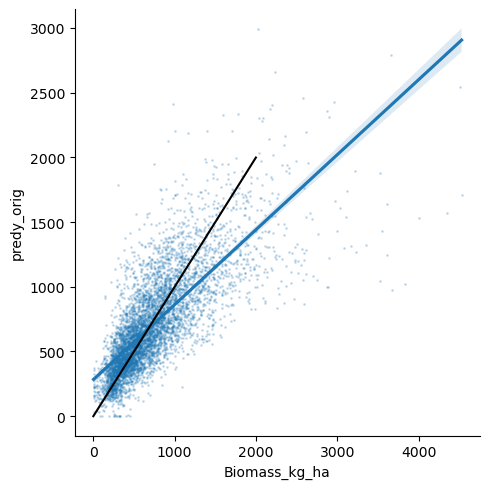

In [60]:
p = sns.lmplot(x='Biomass_kg_ha', y='predy_orig', data=df2, scatter_kws={'s': 1, 'alpha': 0.2})
p.axes.flatten()[0].plot(np.arange(0, 2000), np.arange(0,2000), c='k')

In [61]:
df3 = pd.merge(df, df2[['Id', 'Pasture', 'Year', 'Date_mean', 'predy', 'predy_orig']],
               how='left', on=['Id', 'Pasture', 'Year', 'Date_mean'])

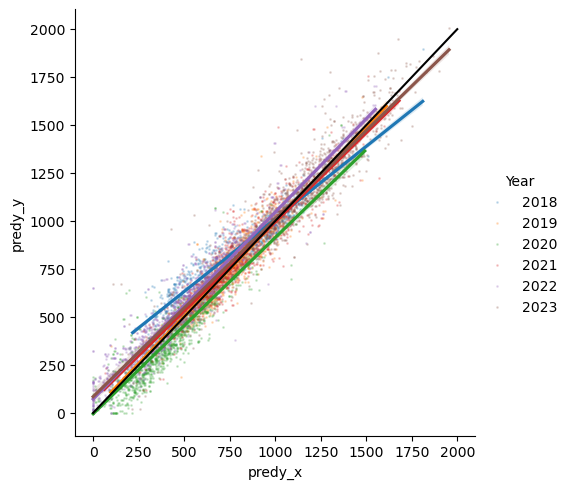

In [62]:
p = sns.lmplot(x='predy_x', y='predy_y', data=df3, hue='Year', scatter_kws={'s': 1, 'alpha': 0.2})
p.axes.flatten()[0].plot(np.arange(0, 2000), np.arange(0,2000), c='k')

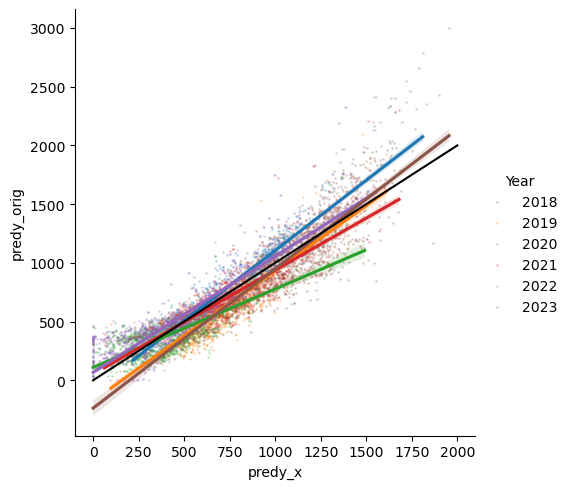

In [63]:
p = sns.lmplot(x='predy_x', y='predy_orig', data=df3, hue='Year', scatter_kws={'s': 1, 'alpha': 0.2})
p.axes.flatten()[0].plot(np.arange(0, 2000), np.arange(0,2000), c='k')

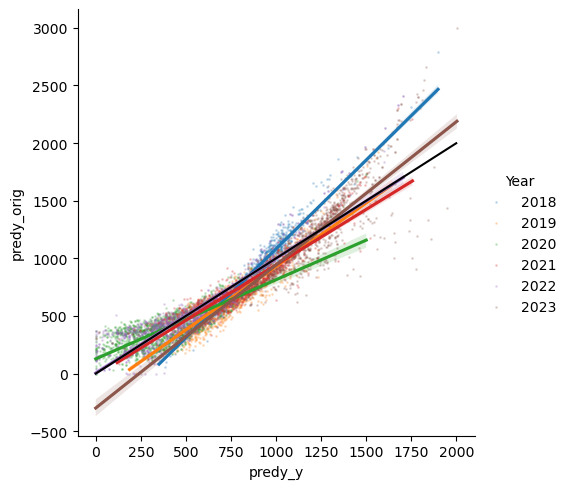

In [64]:
p = sns.lmplot(x='predy_y', y='predy_orig', data=df3, hue='Year', scatter_kws={'s': 1, 'alpha': 0.2})
p.axes.flatten()[0].plot(np.arange(0, 2000), np.arange(0,2000), c='k')

In [117]:
mae_plot = df.groupby(kfold_group).apply(lambda z: z.groupby(['Id', 'Date']).apply(
        lambda x: abs(np.mean(x['PLS_pred']) - np.mean(x['sqrt_Biomass_kg_ha'])), 
        include_groups=False).mean(), include_groups=False).round(4)
bias_plot = df.groupby(kfold_group).apply(lambda z: z.groupby(['Id', 'Date']).apply(
        lambda x: np.mean(x['PLS_pred']) - np.mean(x['sqrt_Biomass_kg_ha']),
        include_groups=False).mean(), include_groups=False).round(4)
mae_bt_plot = df.groupby(kfold_group).apply(lambda z: z.groupby(['Id', 'Date']).apply(
        lambda x: abs(np.mean(x['PLS_pred']**2) - np.mean(x['Biomass_kg_ha'])), 
        include_groups=False).mean(), include_groups=False).round(4)
bias_bt_plot = df.groupby(kfold_group).apply(lambda z: z.groupby(['Id', 'Date']).apply(
        lambda x: np.mean(x['PLS_pred']**2) - np.mean(x['Biomass_kg_ha']), 
        include_groups=False).mean(), include_groups=False).round(4)

In [118]:
df_id_means = df.groupby(kfold_group).apply(lambda z: z[['Id', 'Date', 'sqrt_Biomass_kg_ha', 'PLS_pred']].groupby(
    ['Id', 'Date'], observed=True).mean(), include_groups=False).reset_index().dropna()
r2_plot = df_id_means.groupby(kfold_group).apply(lambda z: r2_score(z['sqrt_Biomass_kg_ha'], z['PLS_pred']),
                                                include_groups=False).round(4)
r2_corr_plot = df_id_means.groupby(kfold_group).apply(lambda z: r_corrcoef(z['sqrt_Biomass_kg_ha'], z['PLS_pred']),
                                                     include_groups=False).round(4)

In [119]:
df_smry_plot = pd.DataFrame({
    'MAE': mae_plot.mean().round(4),
    'MAE_std': mae_plot.std().round(4),
    'Bias': bias_plot.mean().round(4),
    'Bias_std': bias_plot.std().round(4),
    'R^2': r2_plot.mean().round(4),
    'R^2_std': r2_plot.std().round(4),
    'r': r2_corr_plot.mean().round(4),
    'r_std': r2_corr_plot.std().round(4),
    'MAE_bt': mae_bt_plot.mean().round(4),
    'MAE_bt_std': mae_bt_plot.std().round(4),
    'MAE_bt_pct': (mae_bt_plot / df.groupby([kfold_group], 
                                                    observed=True)['Biomass_kg_ha'].mean()).mean().round(4),
    'MAE_bt_pct_std': (mae_bt_plot / df.groupby([kfold_group], 
                                                    observed=True)['Biomass_kg_ha'].mean()).std().round(4),
    'Bias_bt': bias_bt_plot.mean().round(4),
    'Bias_bt_std': bias_bt_plot.std().round(4),
}, index=[0])
display(df_smry_plot)
#if save_results:
#    df_smry_plot.to_csv(os.path.join(outDIR,
#                                     'tables/ml_models', 
#                                     re.sub('tmp.csv', 'results_plot.csv', os.path.basename(inPATH))))

df_smry_plot_by_yr = pd.DataFrame({
    'MAE': mae_plot.round(4),
    'Bias': bias_plot.round(4),
    'MAE_bt': mae_bt_plot.round(4),
    'MAE_pct': (mae_bt_plot / df.groupby([kfold_group], observed=True)['Biomass_kg_ha'].mean()).round(4),
    'R^2': r2_plot.round(4),
    'r': r2_corr_plot.round(4)
})
#display(df_smry_plot_by_yr)
#if save_results:
#    df_smry_plot_by_yr.to_csv(os.path.join(outDIR, 
#                                           'tables/ml_models', 
#                                           re.sub('tmp.csv', 'results_plot_yrly.csv', os.path.basename(inPATH))))

,MAE,MAE_std,Bias,Bias_std,R^2,R^2_std,r,r_std,MAE_bt,MAE_bt_std,MAE_bt_pct,MAE_bt_pct_std,Bias_bt,Bias_bt_std
0,4.5737,1.25,0.4658,1.9575,0.2607,0.2642,0.613,0.1307,254.7055,105.3418,0.3574,0.096,6.4283,121.2942


In [120]:
df_smry_plot_by_yr

,MAE,Bias,MAE_bt,MAE_pct,R^2,r
Year,,,,,,
2018,4.1097,-2.1053,251.3083,0.2811,0.5219,0.7692
2019,3.1649,-0.6301,178.8216,0.2335,0.5260,0.7395
2020,4.0871,1.3190,168.3527,0.4224,0.0903,0.5148
2021,4.2222,-0.0123,245.5851,0.3081,0.4463,0.6779
2022,5.0409,0.5346,226.0977,0.4741,-0.0151,0.4874
2023,6.8174,3.6887,458.0677,0.4255,-0.0053,0.4891


In [73]:
df.columns

Index(['Id', 'Pasture', 'Date', 'Date_mean', 'Year', 'Season', 'Low', 'High',
       'Biomass_kg_ha', 'geometry', 'NDVI', 'DFI', 'NDTI', 'SATVI', 'NDII7',
       'SAVI', 'RDVI', 'MTVI1', 'NCI', 'NDCI', 'PSRI', 'NDWI', 'EVI', 'TCBI',
       'TCGI', 'TCWI', 'BAI_126', 'BAI_136', 'BAI_146', 'BAI_236', 'BAI_246',
       'BAI_346', 'BLUE', 'GREEN', 'RED', 'RED-EDGE1', 'RED-EDGE2',
       'RED-EDGE3', 'NIR-Broad', 'NIR1', 'SWIR1', 'SWIR2',
       'sqrt_Biomass_kg_ha', 'PLS_pred', 'kfold'],
      dtype='object')

In [61]:
# Preprocessing steps here
df2 = pd.read_csv(os.path.join(inDIR, 'vor_2014_2023_cln_2024_04_04_' + prefix + '_hls_idxs.csv'),
                  parse_dates=[date_col])
df2_vars = [x for x in var_names if x not in ['RED-EDGE1', 'RED-EDGE2', 'RED-EDGE3', 'NIR-Broad']]
df2 = df2[df2['Season'].isin(['June', 'October'])].copy()

df2 = df2[~df2[df2_vars + ['Biomass_kg_ha']].isnull().any(axis=1)].copy()
df2['sqrt_Biomass_kg_ha'] = np.sqrt(df2['Biomass_kg_ha'])

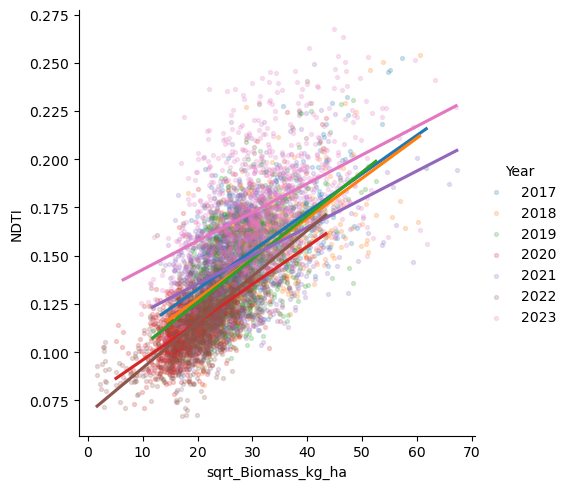

In [63]:
sns.lmplot(df2[df2['Year'] >=2017],
           x='sqrt_Biomass_kg_ha', y='NDTI',
           facet_kws=dict(sharey=False, sharex=False,),
           hue=kfold_group, ci=None,
           scatter_kws={'s': 8, 'alpha': 0.2, 'edgecolor': None})